# Estudio del bandido de k-brazos mediante el algoritmo Softmax con distribución binomial

En este notebook se ejecuta y comenta la ejecución del experimento del bandido de k-brazos mediante el algoritmo Softmax con brazos cuya recompensa viene dada por una función de distribución bonomial.

## Constantes

In [1]:
SEED = 42

K = 10
RUNS = 1000
STEPS = 20_000

SAVE_PLOTS_PATH = "plots/softmax_binomial_dist"

## Librerías

In [2]:
import sys
import random

import numpy as np
from typing import List

sys.path.append('./src')
print(sys.path)

from arms import ArmBinomial, Bandit
from experiment import run_experiment
from algorithms import SoftMax
from plotting import plot_average_rewards, plot_optimal_selections, plot_regret, plot_arm_statistics

['C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\python312.zip', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\DLLs', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none\\Lib', 'C:\\Users\\Usuario\\AppData\\Roaming\\uv\\python\\cpython-3.12.12-windows-x86_64-none', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv', '', 'C:\\Users\\Usuario\\Documents\\UM-MIA\\EML\\dourado-minguell-eml-mia-um-p1\\.venv\\Lib\\site-packages', './src']


## Reproducibilidad

In [3]:
random.seed(SEED)
np.random.seed(SEED)

Asegurar que la generación de números aleatorios es igual para todos los experimentos.

## Experimentación

Se ejecuta la experimentación del problema del bandido de k-brazos durante el número de pasos y ejecuciones definido en las constantes. Posteriormente, se realiza el pertienente estudio de resultados mediantes las gráficas de recompensas promedio, selecciones óptimas, arrepentimiento y estadísticas por brazo.

In [4]:
# Creación del bandido de k-brazos
bandit = Bandit(arms=ArmBinomial.generate_arms(K))
optimal_arm = bandit.optimal_arm

print(bandit)
print(f"Optimal arm: {optimal_arm + 1} with expected reward={bandit.get_expected_value(optimal_arm)}")

Bandit with 10 arms: ArmBinomial (n=100, p=0.39), ArmBinomial (n=100, p=0.91), ArmBinomial (n=100, p=0.71), ArmBinomial (n=100, p=0.19), ArmBinomial (n=100, p=0.59), ArmBinomial (n=100, p=0.1), ArmBinomial (n=100, p=0.83), ArmBinomial (n=100, p=0.69), ArmBinomial (n=100, p=0.07), ArmBinomial (n=100, p=0.92)
Optimal arm: 10 with expected reward=0.92


Para le experimentación, se va emplear un bandido de 10 brazos. Para este caso reproducible, el brazo óptimo es el número 10 con una recompensa media esperada de 0.92. Se van a comparar los resultados con distintos valores para la temperatura:
 - temperature = 0.01
 - temperature = 0.1
 - temperature = 1
 - temperature = 5

In [5]:
# Definir los algoritmos softmax con diferente epsilon
algorithms_softmax = [
    SoftMax(k=K, temperature=0.01),
    SoftMax(k=K, temperature=0.1),
    SoftMax(k=K, temperature=1),
    SoftMax(k=K, temperature=5)
]

# Ejecutar el experimento
rewards_softmax, optimal_selections_softmax, regret_accumulated_softmax, arm_stats_softmax = run_experiment(bandit, algorithms_softmax, STEPS, RUNS)

Ya se han definido los algoritmos y ejecutada la experimentación. A continuación, se van a comentar los resultados obetnidos mediante las correspondientes gráficas.

#### Recompensas promedio

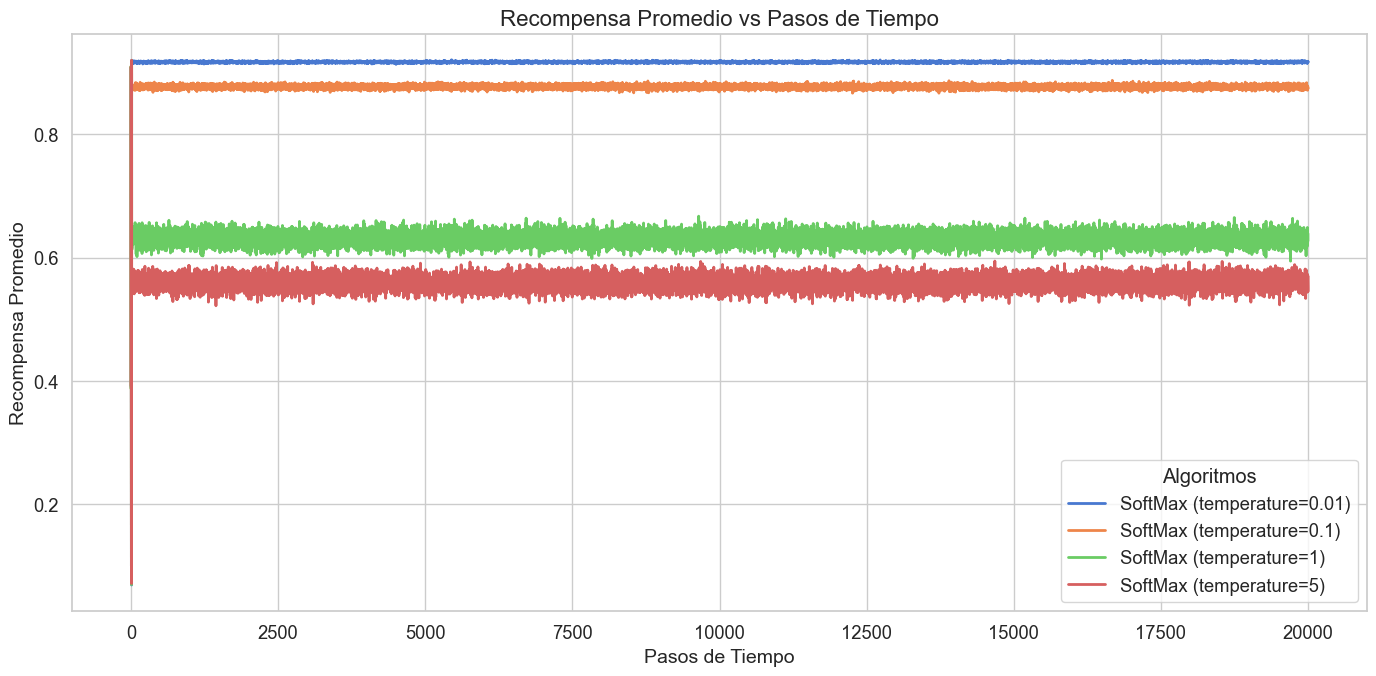

In [6]:
plot_average_rewards(STEPS, rewards_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

Utilizando una distribución de recompensas binomial, el algoritmo más explotador consigue mejores recomensas promedio que el ligeramente explorador con temperatura 0.1. Esto es algo inusual en los experimentos hasta el momento así que necesitarán más gráficos para sacar una hipótesis de qué puede estar ocurriendo.

#### Selecciones óptimas

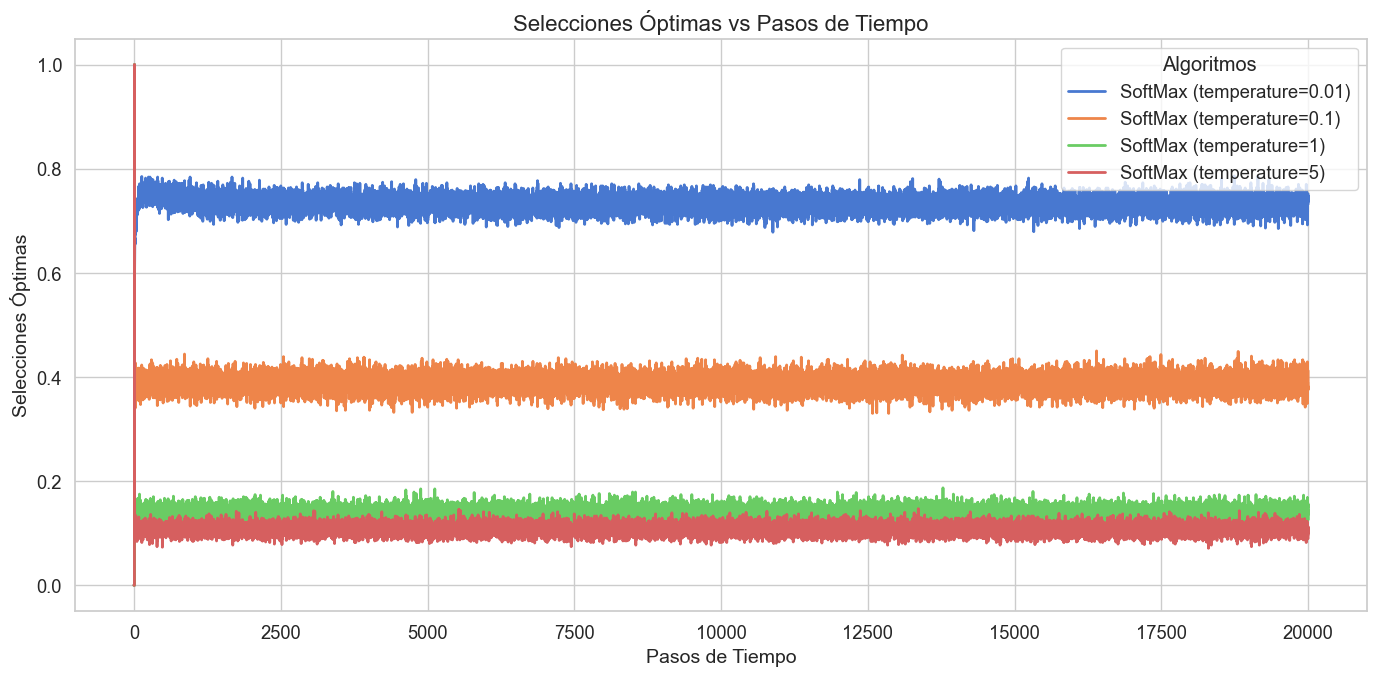

In [7]:
plot_optimal_selections(STEPS, optimal_selections_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

El porcentaje de selecciones óptimas no se acerca al 100% con ninguna configuración. La mejor con temperatura 0.01 no consigue alcanzar el 80%. La segunda mejor, con temperatura 0.1 consigue aproximadamente la mitad.

#### Arrepentimiento

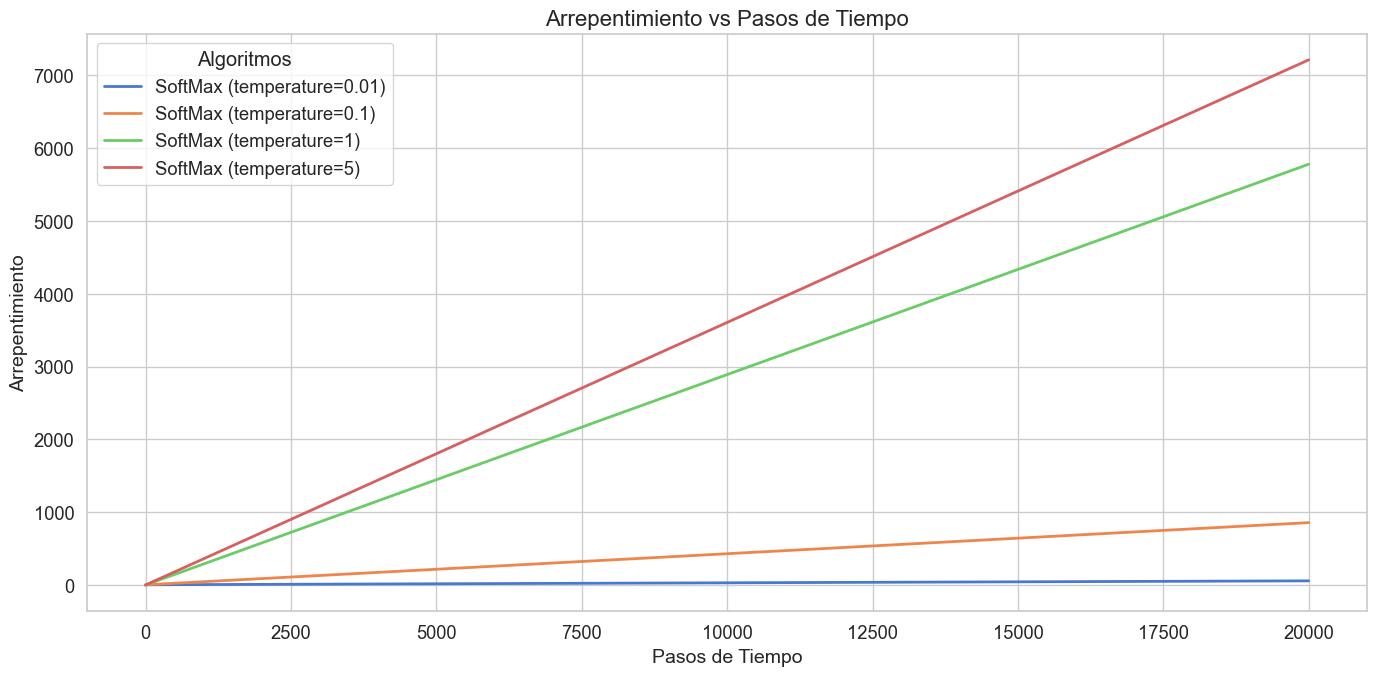

In [8]:
plot_regret(STEPS, regret_accumulated_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

El arrepentimiento acumulado para la versión con temperatura 0.01 se eleva ligeramente con los pasos de tiempo, mientras que para el resto la tendencia ascendente es más pronunciada.

#### Estadísticas por brazo

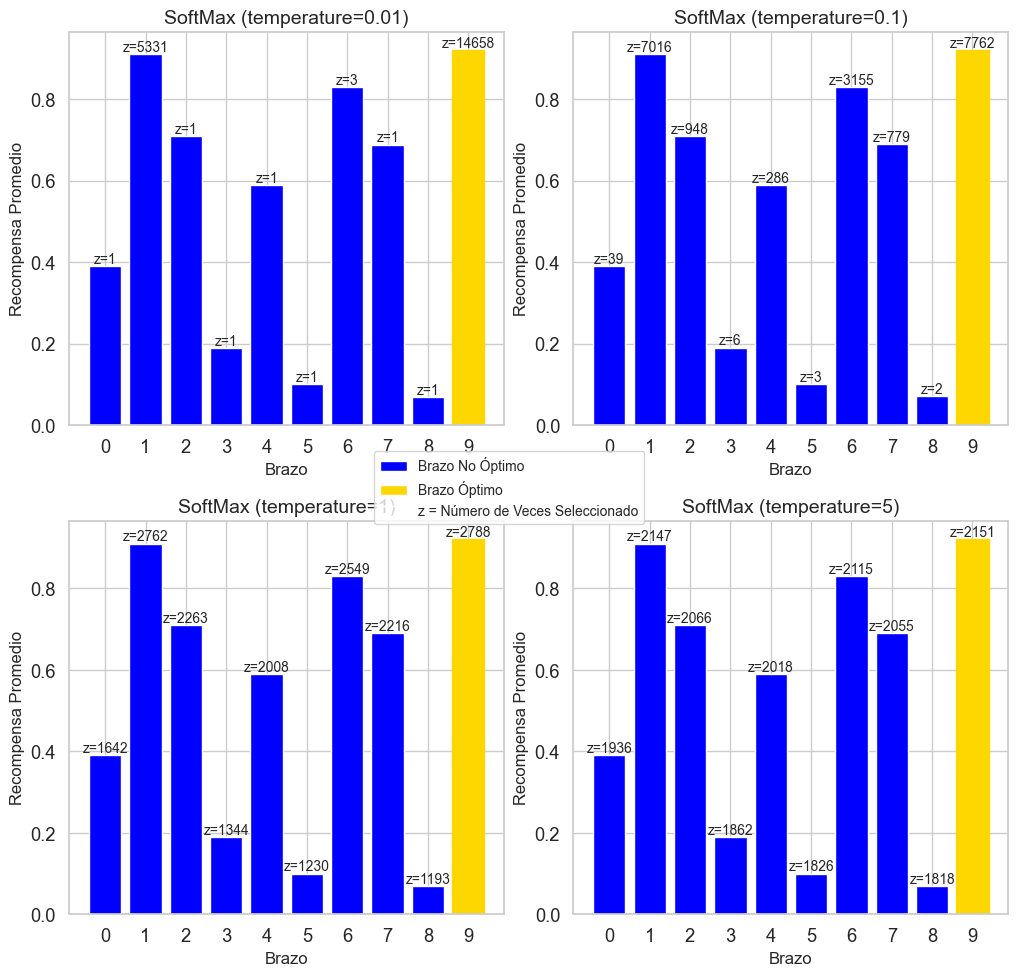

In [9]:
plot_arm_statistics(arm_stats_softmax, algorithms_softmax, SAVE_PLOTS_PATH)

Las estadísticas por brazo nos ayuda a ver por qué el algoritmo más explotador es el que mejor se ha comportado. Los dos mejores brazos tienen un valor medio muy similar. Por eso, aunque la temperatura tenga un valor muy bajo la probabilidad de elegir uno u otro es muy similar y estarán más cercanos cuanto mayor sea la temperatura. Aun así, todos los algoritmos han seleccionado el brazo óptimo la mayoría de las veces aunque en la temperatura 1 y 5 están muy igualados.

## Conclusiones

Gracias a este notebook se aprecia la importancia de la componente exploratoria cuando los dos mejores brazos ofrecen una recompensa muy similar. En estos casos, un valor de exploración más alto de lo óptimo puede hacer que la probabilidad de los dos primeros brazos sea similar y haga bajar el número de selecciones óptimas y, por tanto, aumentar el arrepentimiento.